In [1]:
import pandas as pd
import sys
import os
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset, random_split
import pandas as pd
import numpy as np
import torch.nn.functional as F
import logging
from tqdm import tqdm
from torch.optim.lr_scheduler import StepLR

# Load your data
X_path = '/kaggle/input/soyabean-usda/FINAL_USDA_GENOTYPE.csv'
y_path = '/kaggle/input/soyabean-usda/final_phenotype3.csv'

X_df = pd.read_csv(X_path)
y_df = pd.read_csv(y_path)


In [2]:
X_df.head()

,rs#,ss715578788,ss715578818,ss715578923,ss715578960,ss715579193,ss715579265,ss715579576,ss715579942,ss715580755,...,ss715608835,ss715608836,ss715603654,ss715584705,ss715639159,ss715639176,ss715586962,ss715623959,ss715584606,ss715633065
0,PI587583B,A,C,A,G,C,C,A,G,C,...,G,A,G,A,A,N,A,C,T,C
1,PI417502,A,C,A,G,C,C,A,G,C,...,A,C,G,G,A,T,G,T,T,C
2,PI548973,A,C,A,G,C,C,A,G,C,...,G,C,G,G,A,N,A,C,T,C
3,PI566991,A,C,A,G,C,C,A,G,C,...,A,C,G,G,A,T,G,C,T,C
4,PI567299A,A,C,A,G,C,C,A,G,C,...,A,C,G,A,A,T,G,T,T,C


In [3]:
y_19 = y_df["HEIGHT"]
y_df.head()


,rs#,HEIGHT,OIL,PROTEIN,YIELD
0,PI587583B,102,16.8,45.6,2.08
1,PI417502,163,19.2,42.9,1.54
2,PI548973,152,15.6,47.3,0.12
3,PI566991,200,14.1,48.2,0.48
4,PI567299A,82,13.7,44.5,1.20


In [4]:
snp_encoding = {
    'A': 0, 'C': 2, 'G': 2, 'T': 0,  # Homozygotes as 0
    'R': 1, 'Y': 1, 'S': 1, 'W': 1, 'K': 1, 'M': 1  # Heterozygotes as 1
}

def encode_snp(df):
    """Convert SNPs in DataFrame to codes using snp_encoding_new."""
    df = df.fillna(-1)  # Fill missing values with -1 first
    return df.apply(lambda col: col.map(snp_encoding).fillna(-1))  # map and fill back NaNs with -1

def preprocess_genotype(df):
    """Drop SNP IDs if present, encode, and convert to float32 array."""
    if 'rs#' in df.columns:
        df = df.drop(columns=['rs#'])

    encoded_df = encode_snp(df)

    return encoded_df.values.astype(np.float32)

# Preprocess the data
X = preprocess_genotype(X_df)


In [5]:
X

array([[0., 2., 0., ..., 2., 0., 2.],
       [0., 2., 0., ..., 0., 0., 2.],
       [0., 2., 0., ..., 2., 0., 2.],
       ...,
       [0., 2., 0., ..., 2., 0., 2.],
       [0., 2., 0., ..., 2., 0., 2.],
       [2., 0., 2., ..., 2., 0., 2.]], dtype=float32)

In [6]:
import pandas as pd

X = pd.DataFrame(X)
X.head()

,0,1,2,3,4,5,6,7,8,9,...,42281,42282,42283,42284,42285,42286,42287,42288,42289,42290
0,0.0,2.0,0.0,2.0,2.0,2.0,0.0,2.0,2.0,2.0,...,2.0,0.0,2.0,0.0,0.0,-1.0,0.0,2.0,0.0,2.0
1,0.0,2.0,0.0,2.0,2.0,2.0,0.0,2.0,2.0,2.0,...,0.0,2.0,2.0,2.0,0.0,0.0,2.0,0.0,0.0,2.0
2,0.0,2.0,0.0,2.0,2.0,2.0,0.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,0.0,-1.0,0.0,2.0,0.0,2.0
3,0.0,2.0,0.0,2.0,2.0,2.0,0.0,2.0,2.0,2.0,...,0.0,2.0,2.0,2.0,0.0,0.0,2.0,2.0,0.0,2.0
4,0.0,2.0,0.0,2.0,2.0,2.0,0.0,2.0,2.0,2.0,...,0.0,2.0,2.0,0.0,0.0,0.0,2.0,0.0,0.0,2.0


In [7]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import logging
from tqdm import tqdm

# Set up logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

In [8]:
# Autoencoder Definition
class GeneticAutoencoder(nn.Module):
    def __init__(self, input_dim, encoding_dim):
        
        super(GeneticAutoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 2048),
            nn.BatchNorm1d(2048),
            nn.LeakyReLU(),
            nn.Dropout(0.3),

            nn.Linear(2048,1024 ),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(),
            nn.Dropout(0.3),

            nn.Linear(1024,512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, encoding_dim),
            nn.Sigmoid()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(),
            nn.Dropout(0.3),

            nn.Linear(1024, 2048),
            nn.BatchNorm1d(2048),
            nn.LeakyReLU(),
            nn.Dropout(0.2),

            nn.Linear(2048, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded, encoded 
        
    def fit(self,
            X_train, X_val,
            epochs: int = 500,
            batch_size: int = 32,
            lr: float = 1e-2,
            patience: int = 50,
            use_dataparallel: bool = True,
            distributed: bool = False):
        """
        Train on one or multiple GPUs.
        
        Args:
            use_dataparallel: if True and CUDA_VISIBLE_DEVICES >1, wraps model in nn.DataParallel.
            distributed: if True, assumes you launched via torch.distributed.launch
                         and wraps model in DistributedDataParallel.
        """
        # 1) Device & (optional) DDP init
        if distributed:
            torch.distributed.init_process_group(backend='nccl')
            local_rank = torch.distributed.get_rank()
            torch.cuda.set_device(local_rank)
            device = torch.device("cuda", local_rank)
        else:
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
        self.to(device)
        
        # 2) (optional) wrap for multi‐GPU
        if distributed:
            self = nn.parallel.DistributedDataParallel(self, device_ids=[local_rank], output_device=local_rank)
        elif use_dataparallel and torch.cuda.device_count() > 1:
            self = nn.DataParallel(self)

        # 3) Make Datasets + (optional) DistributedSampler
        def make_loader(X, shuffle):
            if hasattr(X, 'values'):
                X = X.values
            t = torch.from_numpy(X).float()
            ds = TensorDataset(t, t)
            if distributed:
                sampler = DistributedSampler(ds, shuffle=shuffle)
                return DataLoader(ds, batch_size=batch_size, sampler=sampler)
            else:
                return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

        train_loader = make_loader(X_train, shuffle=True)
        val_loader   = make_loader(X_val,   shuffle=False)

        # 4) Opt / loss / sched
        criterion = nn.MSELoss()
        optimizer = optim.Adam(self.parameters(), lr=lr)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=patience//2)

        best_state = copy.deepcopy(self.state_dict())
        best_val   = float('inf')
        no_improve = 0

        history = {'train_loss': [], 'val_loss': []}

        for epoch in range(1, epochs+1):
            # — Training —
            if distributed:
                train_loader.sampler.set_epoch(epoch)
            self.train()
            running_train = 0.0
            for xb, _ in train_loader:
                xb = xb.to(device)
                optimizer.zero_grad()
                xb_recon, _ = self(xb)
                loss = criterion(xb_recon, xb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.parameters(), 1.0)
                optimizer.step()
                running_train += loss.item()
            train_loss = running_train / len(train_loader)

            # — Validation —
            self.eval()
            running_val = 0.0
            with torch.no_grad():
                for xb, _ in val_loader:
                    xb = xb.to(device)
                    xb_recon, _ = self(xb)
                    running_val += criterion(xb_recon, xb).item()
            val_loss = running_val / len(val_loader)

            history['train_loss'].append(train_loss)
            history['val_loss'].append(val_loss)
            scheduler.step(val_loss)

            # — Early Stopping —
            if val_loss < best_val:
                best_val = val_loss
                best_state = copy.deepcopy(self.state_dict())
                no_improve = 0
            else:
                no_improve += 1
                if no_improve >= patience:
                    print(f"[Early stopping] Epoch {epoch}")
                    break

            if epoch % 10 == 0 or epoch == epochs:
                lr_now = optimizer.param_groups[0]['lr']
                print(f"Epoch {epoch:03d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | LR: {lr_now:.2e}")

        self.load_state_dict(best_state)
        return history

In [9]:
# Prepare your data first
X = preprocess_genotype(X_df)  # Should produce a numpy array of shape (samples, features)
input_dim = X.shape[1]  # <- this is crucial



In [10]:
X

array([[0., 2., 0., ..., 2., 0., 2.],
       [0., 2., 0., ..., 0., 0., 2.],
       [0., 2., 0., ..., 2., 0., 2.],
       ...,
       [0., 2., 0., ..., 2., 0., 2.],
       [0., 2., 0., ..., 2., 0., 2.],
       [2., 0., 2., ..., 2., 0., 2.]], dtype=float32)

In [11]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, DistributedSampler
from sklearn.model_selection import train_test_split


# 1) Preprocess & split your genotype DataFrame:
                        # your preprocessing
X_train, X_val = train_test_split(                     # split into 80/20
    X, test_size=0.2
)

# 2) Instantiate and fit:
model = GeneticAutoencoder(input_dim=X_train.shape[1], encoding_dim=128)

# (a) Simple multi‐GPU on one machine:
history = model.fit(
    X_train, X_val,
    epochs=300,
    batch_size=32,
    lr=0.0005,
    patience=50,
    use_dataparallel=True,
    distributed=False
)


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/linear.py:125: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:180.)
  return F.linear(input, self.weight, self.bias)


Epoch 010 | Train: 0.7611 | Val: 0.7575 | LR: 5.00e-04
Epoch 020 | Train: 0.7464 | Val: 0.7470 | LR: 5.00e-04
Epoch 030 | Train: 0.7378 | Val: 0.7411 | LR: 5.00e-04
Epoch 040 | Train: 0.7313 | Val: 0.7353 | LR: 5.00e-04
Epoch 050 | Train: 0.7254 | Val: 0.7319 | LR: 5.00e-04
Epoch 060 | Train: 0.7215 | Val: 0.7299 | LR: 5.00e-04
Epoch 070 | Train: 0.7168 | Val: 0.7272 | LR: 5.00e-04
Epoch 080 | Train: 0.7124 | Val: 0.7262 | LR: 5.00e-04
Epoch 090 | Train: 0.7088 | Val: 0.7237 | LR: 5.00e-04
Epoch 100 | Train: 0.7040 | Val: 0.7228 | LR: 5.00e-04
Epoch 110 | Train: 0.7009 | Val: 0.7209 | LR: 5.00e-04
Epoch 120 | Train: 0.6990 | Val: 0.7210 | LR: 5.00e-04
Epoch 130 | Train: 0.6981 | Val: 0.7197 | LR: 5.00e-04
Epoch 140 | Train: 0.6945 | Val: 0.7185 | LR: 5.00e-04
Epoch 150 | Train: 0.6926 | Val: 0.7178 | LR: 5.00e-04
Epoch 160 | Train: 0.6890 | Val: 0.7187 | LR: 5.00e-04
Epoch 170 | Train: 0.6875 | Val: 0.7167 | LR: 5.00e-04
Epoch 180 | Train: 0.6867 | Val: 0.7162 | LR: 5.00e-04
Epoch 190 

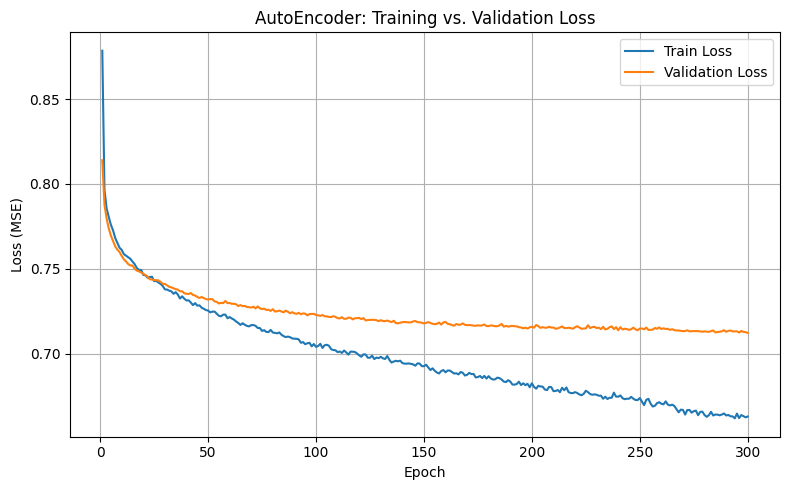

Model weights saved to checkpoints/autoencoder_weights.pth


In [12]:
train_loss = history['train_loss']
val_loss   = history['val_loss']

# Epoch indices
epochs_train = list(range(1, len(train_loss) + 1))
epochs_val   = list(range(1, len(val_loss)   + 1))

plt.figure(figsize=(8, 5))
plt.plot(epochs_train, train_loss, label='Train Loss')
plt.plot(epochs_val,   val_loss,  label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('AutoEncoder: Training vs. Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
# Make sure your save directory exists
save_dir = "checkpoints"
os.makedirs(save_dir, exist_ok=True)

# If you used DataParallel, unwrap to the original module
net = model.module if hasattr(model, "module") else model

# Save the state_dict (weights + buffers)
save_path = os.path.join(save_dir, "autoencoder_weights.pth")
torch.save(net.state_dict(), save_path)

print(f"Model weights saved to {save_path}")

In [13]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr

# --------------------------
# 1. Prepare Dataset Class
# --------------------------
class SNPDataset(Dataset):
    def __init__(self, X_df: pd.DataFrame, y_series: pd.Series):
        """
        X_df: DataFrame of shape (n_samples, snp_len)
        y_series: Series of shape (n_samples,)
        """
        self.X = X_df.values.astype(np.float32)            # shape = (n, snp_len)
        self.y = y_series.values.astype(np.float32).reshape(-1, 1)  # shape = (n, 1)
        self.n_samples, self.snp_len = self.X.shape

        # Compute the “image” dimension:
        # First: ceil(snp_len / 24) → how many “pixels” per channel
        blocks = int(np.ceil(self.snp_len / 20))
        # Next: take sqrt and ceil to form a square
        self.num = int(np.ceil(np.sqrt(blocks)))

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        # Get the flat SNP vector for one sample
        flat_vector = self.X[idx]  # shape = (snp_len,)

        img = np.zeros((20, self.num, self.num), dtype=np.float32)
        total_pixels = 20 * self.num * self.num

        # Flatten the img to assign easily, then reshape back
        img_flat = img.reshape(-1)  # length = total_pixels
        img_flat[: self.snp_len] = flat_vector[: self.snp_len]  # copy actual SNP values
        img = img_flat.reshape(20, self.num, self.num)

        # Convert to torch.Tensor
        img_tensor = torch.from_numpy(img)  # shape = (24, num, num)
        y_tensor = torch.from_numpy(self.y[idx])  # shape = (1,)

        return img_tensor, y_tensor


In [14]:
import torch
import numpy as np
from sklearn.svm import SVR
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error

# ── 1) Encode your full dataset ────────────────────────────────────────────────
# Assume X: numpy array of shape (n_samples, n_features)
#         y: numpy array of shape (n_samples,) — your regression targets

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device).eval()
y_arr = y_19.values if hasattr(y_19, 'values') else np.asarray(y_19)
y_arr = y_arr.ravel()   # now guaranteed shape (n_samples,)
# turn X into a torch Tensor, push to device
X_t = torch.from_numpy(X).float().to(device)
with torch.no_grad():
    # encoder returns (reconstruction, code) in our class
    _, Z_t = model(X_t)         # Z_t: torch.Tensor, shape (n_samples, encoding_dim)

# bring back to CPU / numpy
Z = Z_t.cpu().numpy()           # shape (n_samples, encoding_dim)

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from scipy.stats import pearsonr
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

# Define the ResNet-based model for regression using torch.hub
class ResNetRegressor(nn.Module):
    def __init__(self, model_name='resnet18', num_channels=20, pretrained=False):
        super(ResNetRegressor, self).__init__()
        
        # Load ResNet model from torch.hub
        self.resnet = torch.hub.load('pytorch/vision:v0.10.0', model_name, pretrained=pretrained)
        
        # Modify the first convolutional layer to accept 24 channels
        original_conv1 = self.resnet.conv1
        self.resnet.conv1 = nn.Conv2d(
            in_channels=num_channels,
            out_channels=original_conv1.out_channels,
            kernel_size=original_conv1.kernel_size,
            stride=original_conv1.stride,
            padding=original_conv1.padding,
            bias=original_conv1.bias
        )
        
        # If pretrained, initialize new conv1 weights by averaging pretrained weights across channels
        if pretrained:
            with torch.no_grad():
                # Average the 3-channel pretrained weights to initialize the 24-channel layer
                pretrained_weights = original_conv1.weight.mean(dim=1, keepdim=True)  # [out_channels, 1, k, k]
                self.resnet.conv1.weight.copy_(pretrained_weights.repeat(1, num_channels, 1, 1))
        
        # Replace the fully connected layer for regression
        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(0.2),  # Add dropout to prevent overfitting
            nn.Linear(in_features, 1)  # Output a single regression value
        )
        
    def forward(self, x):
        # Pass input through ResNet
        x = self.resnet(x)  # Shape: [batch_size, 1]
        return x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_epochs = 60
batch_size = 32
snp_len = Z.shape[1]  # number of SNP features
saved_model_paths = []



In [16]:
import pandas as pd

Z = pd.DataFrame(Z)           # Only if Z is not already a DataFrame
y_19 = pd.Series(y_19)        # Only if y_19 is not already a Series



=== Outer Fold 1/10 ===
  --- Inner Fold 1/10 ---


Downloading: "https://github.com/pytorch/vision/zipball/v0.10.0" to /root/.cache/torch/hub/v0.10.0.zip


  --- Inner Fold 2/10 ---


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


  --- Inner Fold 3/10 ---


...

Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


  --- Inner Fold 9/10 ---


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


  --- Inner Fold 10/10 ---


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


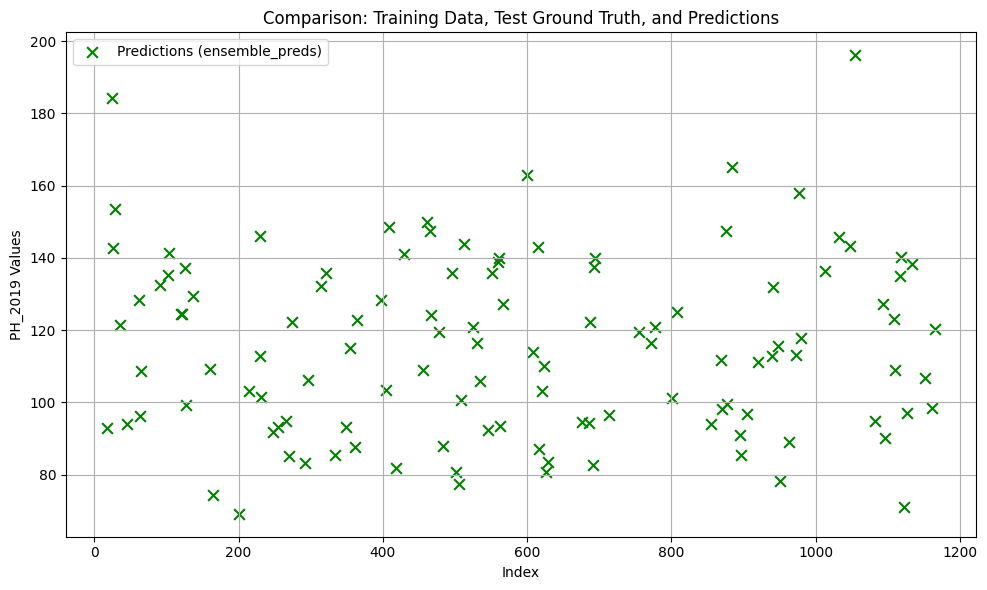

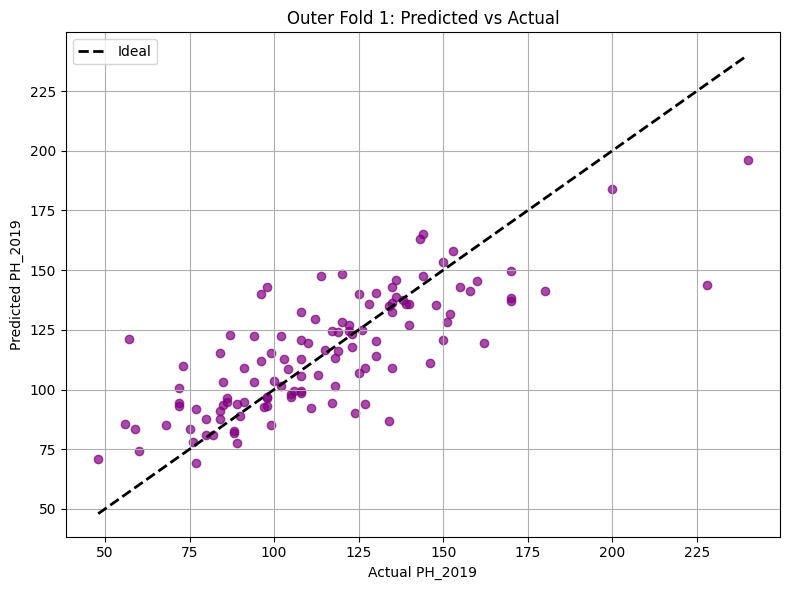

  >> Outer Fold 1 Test PCC: 0.7759, R²: 0.6006, MSE: 434.7169, MAE: 15.3425

=== Outer Fold 2/10 ===
  --- Inner Fold 1/10 ---


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


  --- Inner Fold 2/10 ---


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


  --- Inner Fold 3/10 ---


...

Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


  --- Inner Fold 9/10 ---


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


  --- Inner Fold 10/10 ---


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


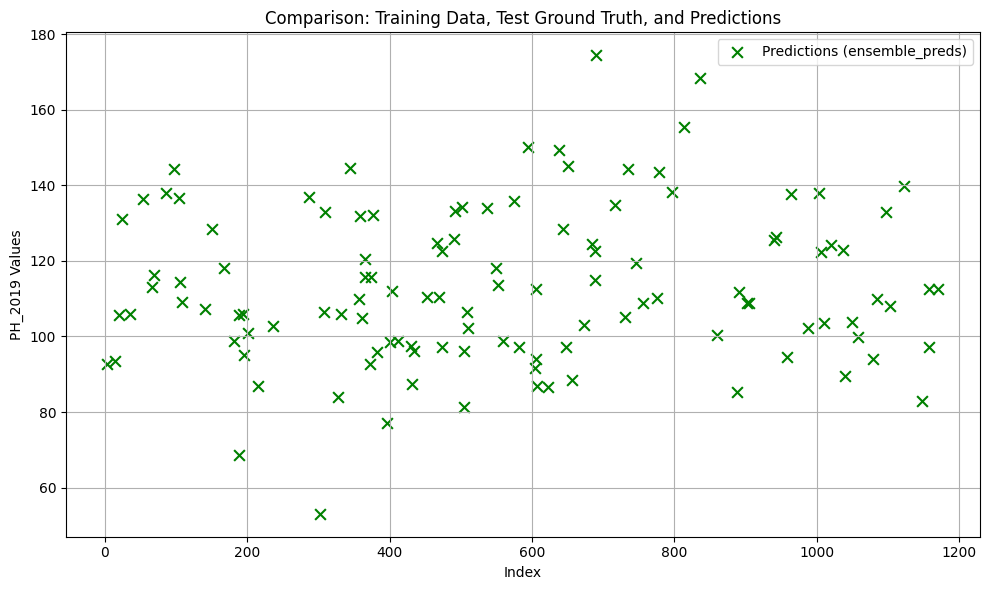

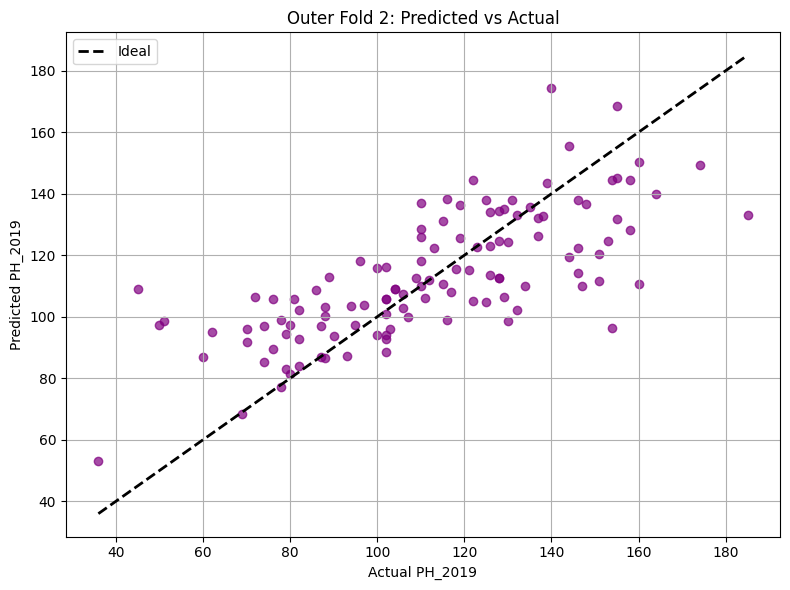

  >> Outer Fold 2 Test PCC: 0.7348, R²: 0.5365, MSE: 412.7441, MAE: 15.5212

=== Outer Fold 3/10 ===
  --- Inner Fold 1/10 ---


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


  --- Inner Fold 2/10 ---


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


  --- Inner Fold 3/10 ---


...

Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


  --- Inner Fold 9/10 ---


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


  --- Inner Fold 10/10 ---


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


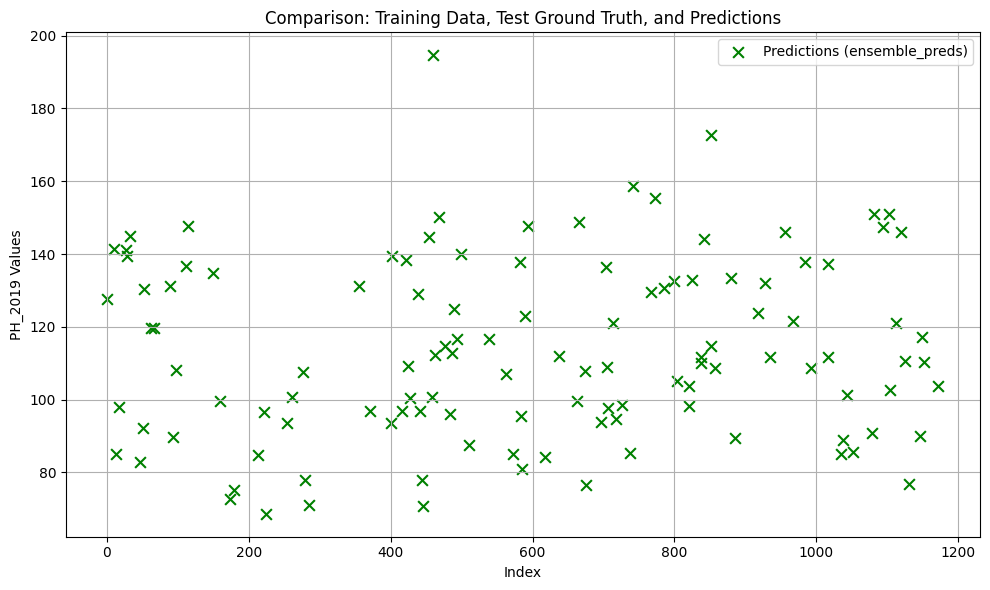

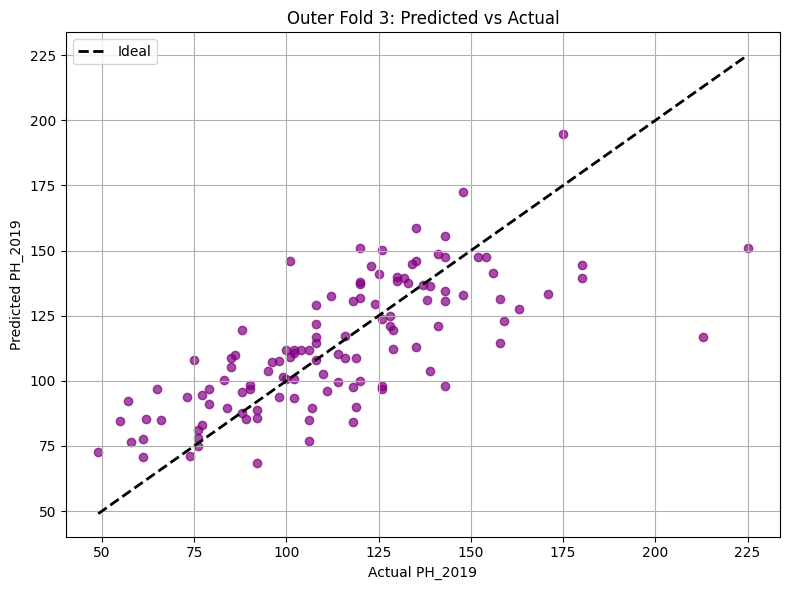

  >> Outer Fold 3 Test PCC: 0.7262, R²: 0.5256, MSE: 484.2716, MAE: 16.6901

=== Outer Fold 4/10 ===
  --- Inner Fold 1/10 ---


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


  --- Inner Fold 2/10 ---


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


  --- Inner Fold 3/10 ---


...

Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


  --- Inner Fold 9/10 ---


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


  --- Inner Fold 10/10 ---


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


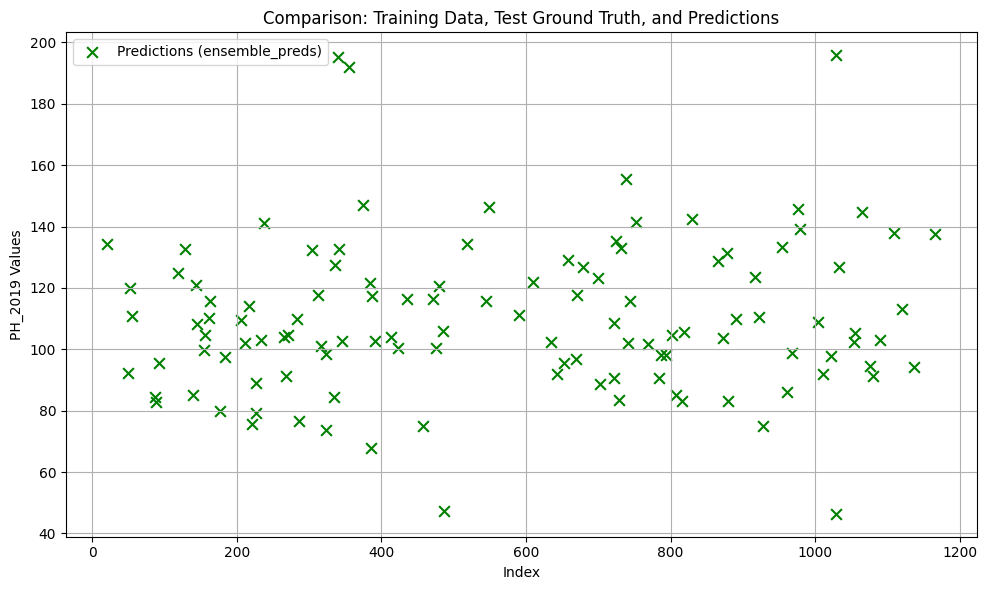

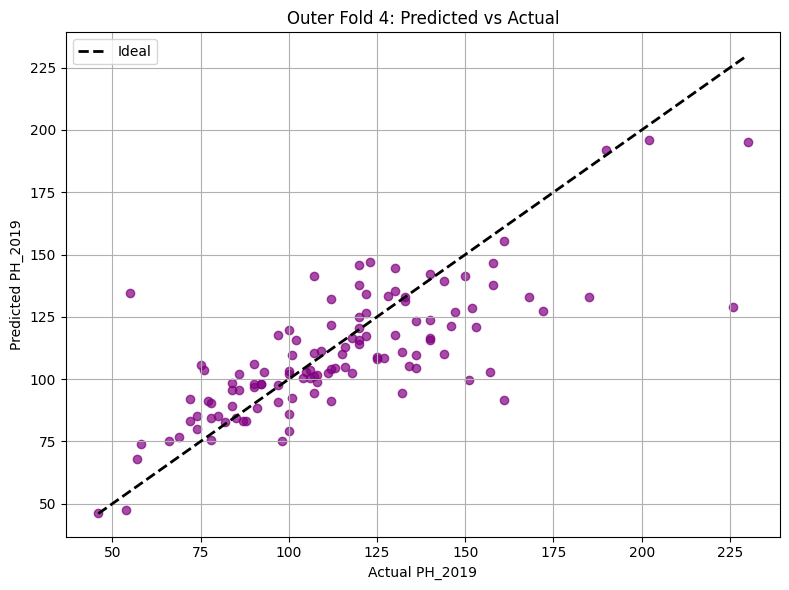

  >> Outer Fold 4 Test PCC: 0.7645, R²: 0.5667, MSE: 486.2710, MAE: 15.3060

=== Outer Fold 5/10 ===
  --- Inner Fold 1/10 ---


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


  --- Inner Fold 2/10 ---


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


  --- Inner Fold 3/10 ---


...

Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


  --- Inner Fold 9/10 ---


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


  --- Inner Fold 10/10 ---


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


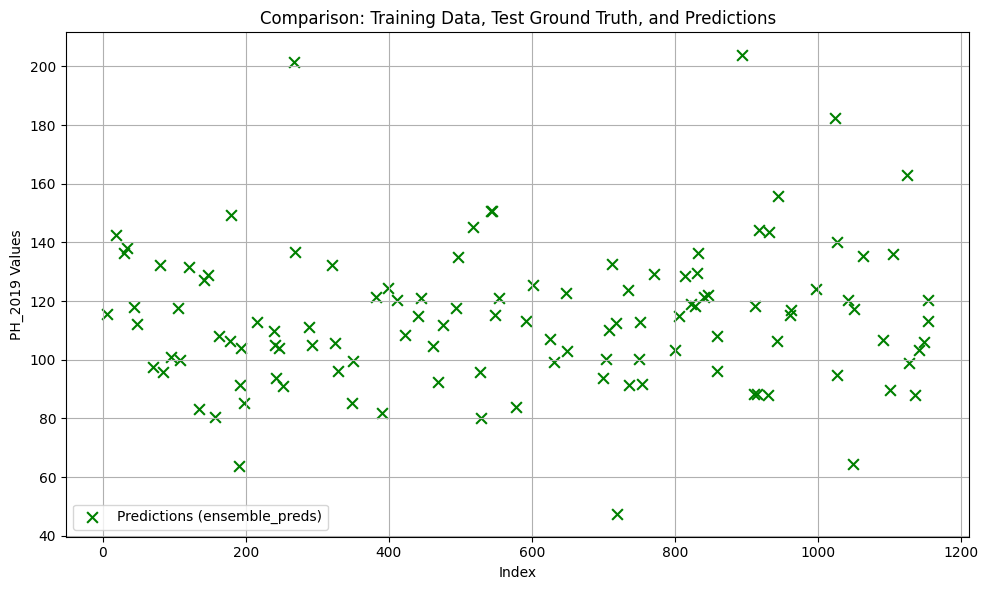

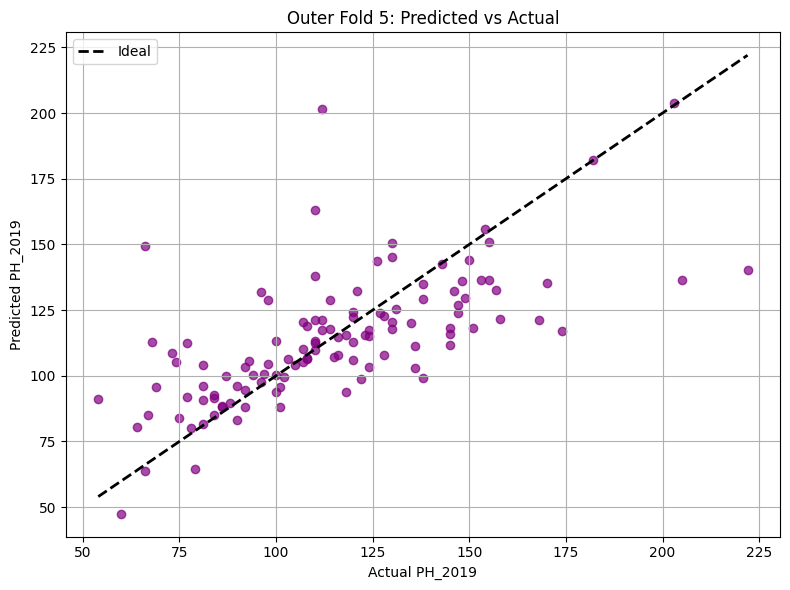

  >> Outer Fold 5 Test PCC: 0.6662, R²: 0.4347, MSE: 563.9719, MAE: 16.1073

=== Outer Fold 6/10 ===
  --- Inner Fold 1/10 ---


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


  --- Inner Fold 2/10 ---


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


  --- Inner Fold 3/10 ---


...

Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


  --- Inner Fold 9/10 ---


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


  --- Inner Fold 10/10 ---


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


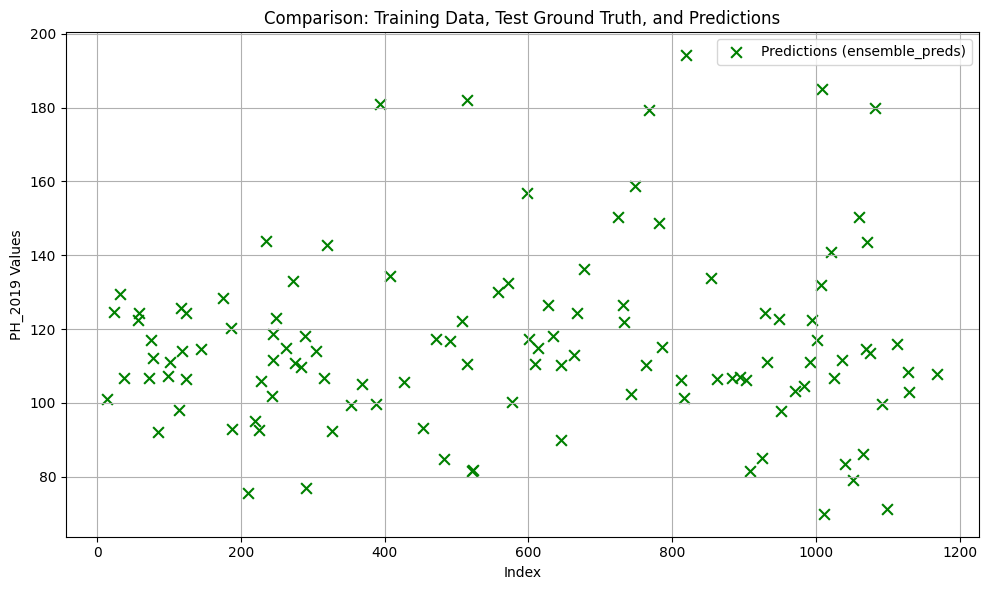

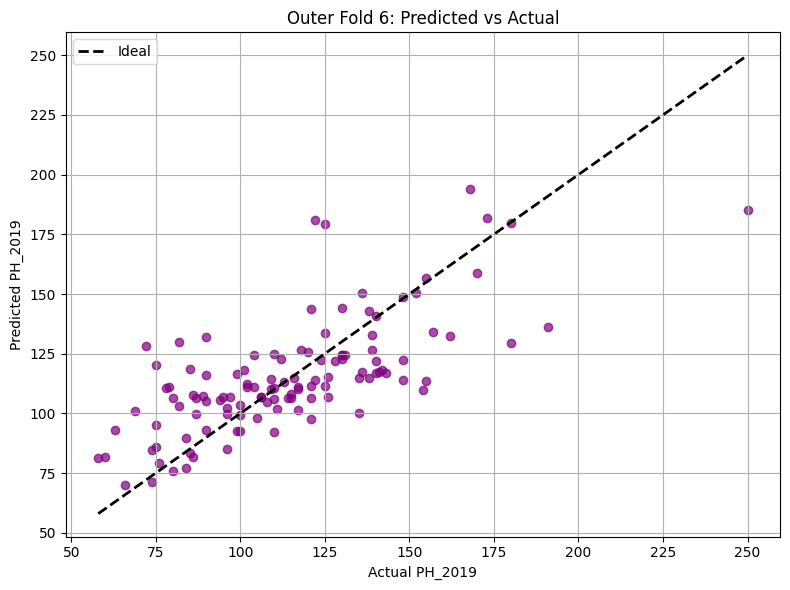

  >> Outer Fold 6 Test PCC: 0.7160, R²: 0.5092, MSE: 471.2191, MAE: 16.1515

=== Outer Fold 7/10 ===
  --- Inner Fold 1/10 ---


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


  --- Inner Fold 2/10 ---


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


  --- Inner Fold 3/10 ---


...

Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


  --- Inner Fold 9/10 ---


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


  --- Inner Fold 10/10 ---


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


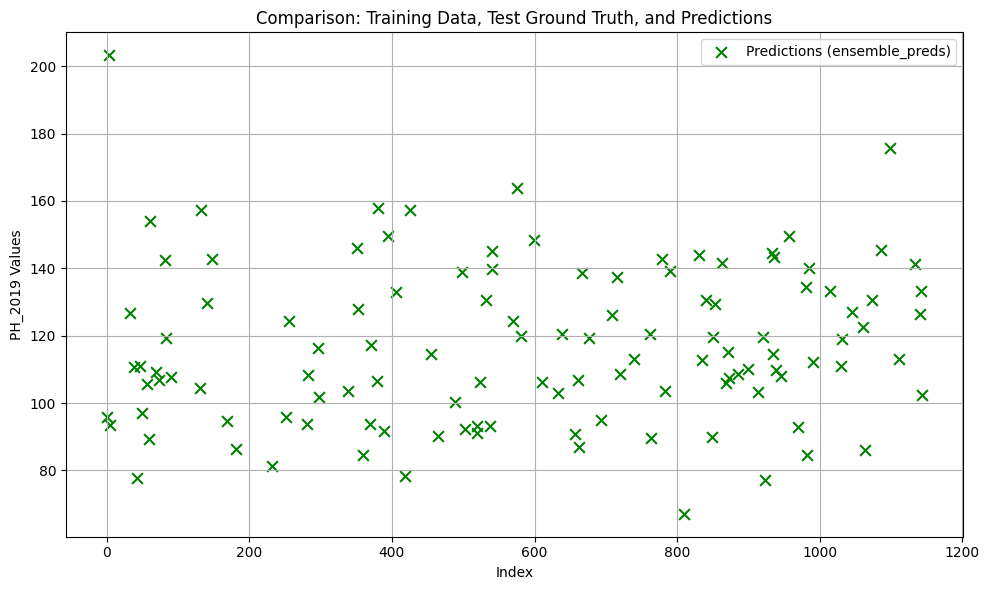

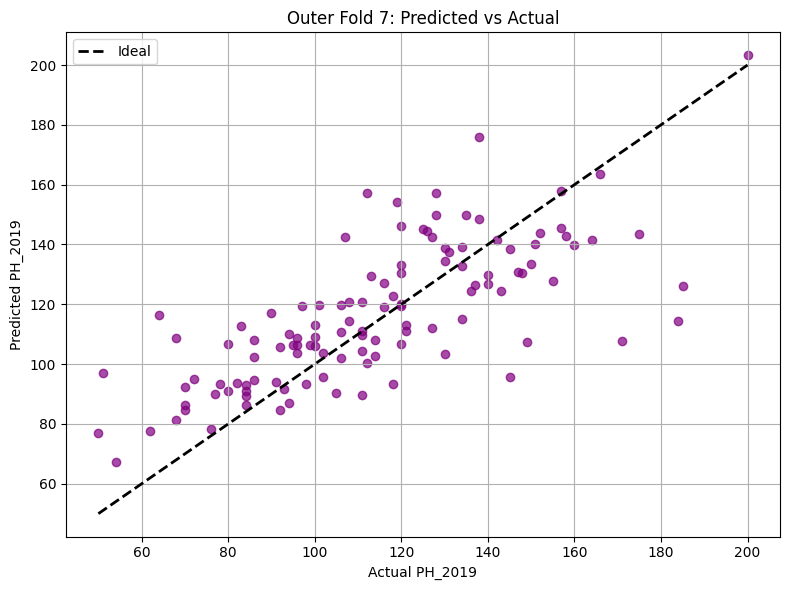

  >> Outer Fold 7 Test PCC: 0.7315, R²: 0.5258, MSE: 436.0866, MAE: 15.9499

=== Outer Fold 8/10 ===
  --- Inner Fold 1/10 ---


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


  --- Inner Fold 2/10 ---


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


  --- Inner Fold 3/10 ---


...

Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


  --- Inner Fold 9/10 ---


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


  --- Inner Fold 10/10 ---


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


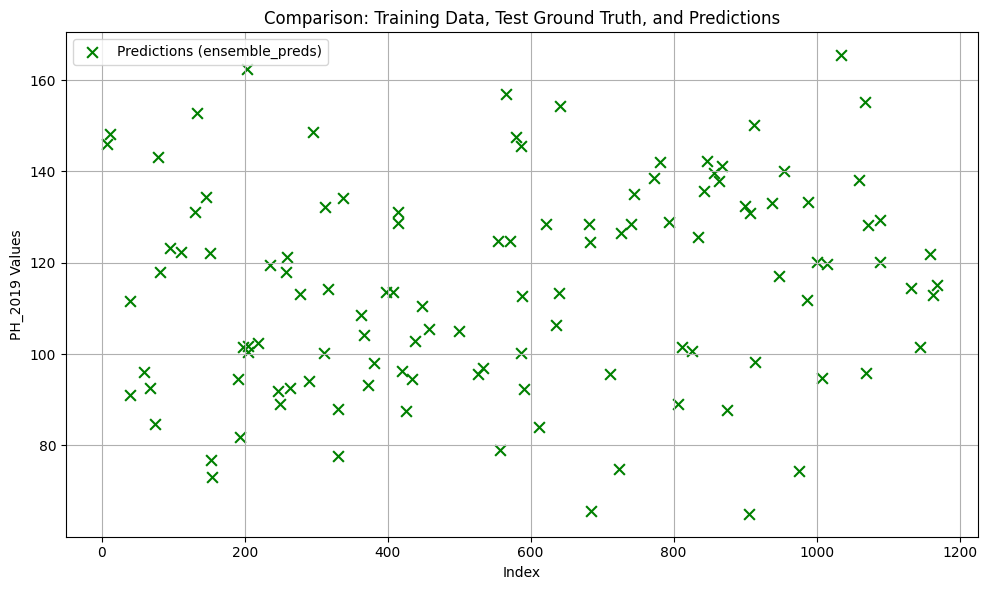

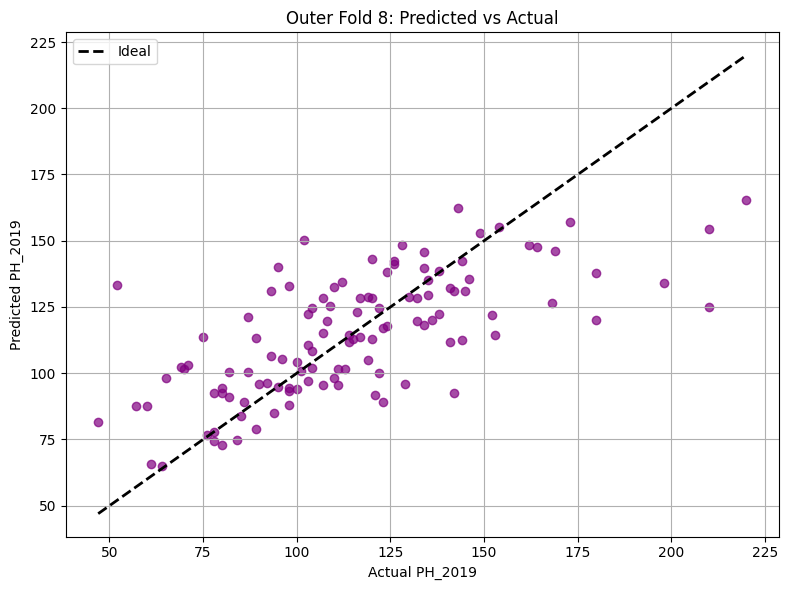

  >> Outer Fold 8 Test PCC: 0.6819, R²: 0.4649, MSE: 597.7964, MAE: 17.7758

=== Outer Fold 9/10 ===
  --- Inner Fold 1/10 ---


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


  --- Inner Fold 2/10 ---


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


  --- Inner Fold 3/10 ---


...

Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


  --- Inner Fold 9/10 ---


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


  --- Inner Fold 10/10 ---


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


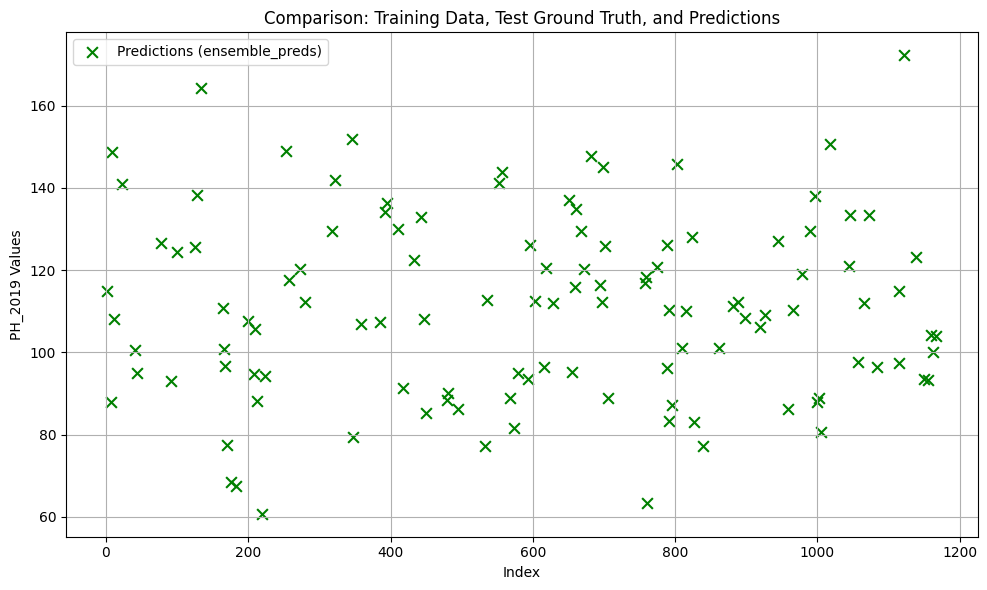

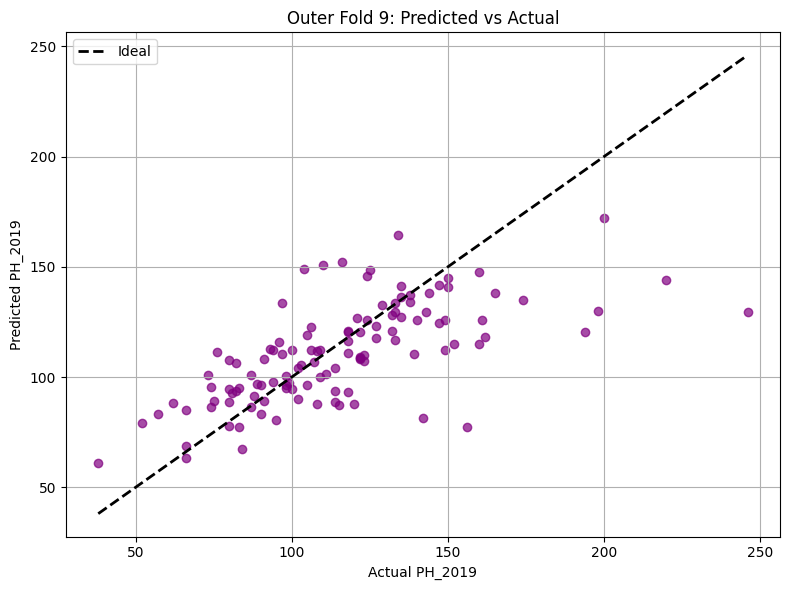

  >> Outer Fold 9 Test PCC: 0.6629, R²: 0.4228, MSE: 667.9063, MAE: 17.9160

=== Outer Fold 10/10 ===
  --- Inner Fold 1/10 ---


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


  --- Inner Fold 2/10 ---


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


  --- Inner Fold 3/10 ---


...

Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


  --- Inner Fold 9/10 ---


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


  --- Inner Fold 10/10 ---


Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0


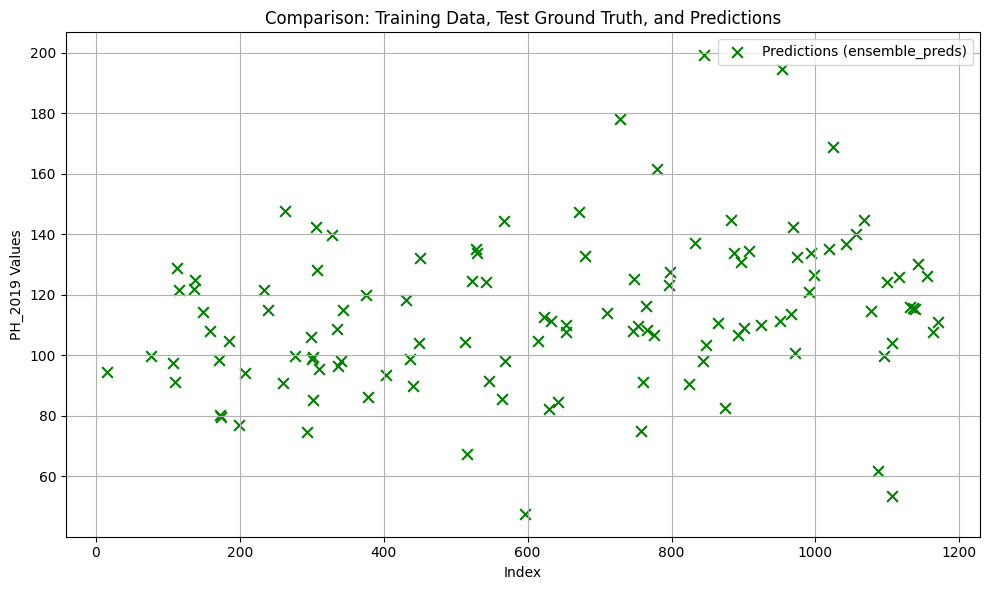

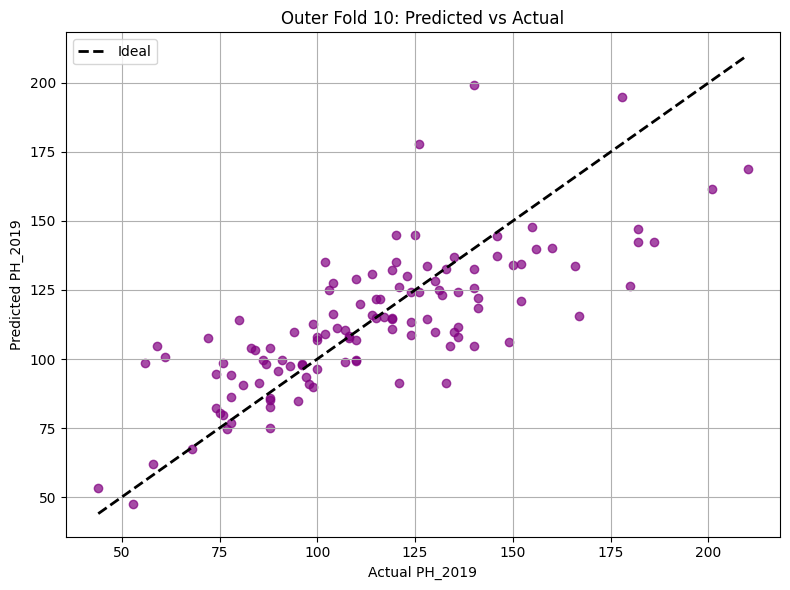

  >> Outer Fold 10 Test PCC: 0.7601, R²: 0.5764, MSE: 439.5414, MAE: 15.6374

=== Final 10-Fold Test Summary ===
  PCC: 0.7220 ± 0.0383
   R2: 0.5163 ± 0.0565
  MSE: 499.4525 ± 79.1997
  MAE: 16.2398 ± 0.8965


In [17]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr
from torch.utils.data import DataLoader
import torch, torch.nn as nn, torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Z = pd.DataFrame(Z)

# --- Config ---
device      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_outer     = 10
n_inner     = 10
num_epochs  = 70
batch_size  = 32

# Convert y to Series
y_19 = pd.Series(y_arr)  # ← FIXED
num_bins = 10
y_binned = np.digitize(y_19, bins=np.quantile(y_19, q=np.linspace(0, 1, num_bins + 1)[1:-1]))

# Store metrics
outer_metrics = {"pcc": [], "r2": [], "mse": [], "mae": []}

# Outer Stratified K-Fold
skf_outer = StratifiedKFold(n_splits=n_outer, shuffle=True)

for outer_fold, (outer_train_idx, outer_test_idx) in enumerate(skf_outer.split(Z, y_binned), 1):
    print(f"\n=== Outer Fold {outer_fold}/{n_outer} ===")

    X_pool, X_test_df = Z.iloc[outer_train_idx], Z.iloc[outer_test_idx]
    y_pool, y_test_ser = y_19.iloc[outer_train_idx], y_19.iloc[outer_test_idx]

    plt.figure(figsize=(10, 6))
   

    y_pool_binned = np.digitize(y_pool, bins=np.quantile(y_pool, q=np.linspace(0, 1, num_bins + 1)[1:-1]))
    saved_model_paths = []

    skf_inner = StratifiedKFold(n_splits=n_inner, shuffle=True)

    for inner_fold, (tr_idx, val_idx) in enumerate(skf_inner.split(X_pool, y_pool_binned), 1):
        print(f"  --- Inner Fold {inner_fold}/{n_inner} ---")

        X_tr, X_val = X_pool.iloc[tr_idx], X_pool.iloc[val_idx]
        y_tr, y_val = y_pool.iloc[tr_idx], y_pool.iloc[val_idx]

        scaler_y = StandardScaler()
        y_tr_sc = scaler_y.fit_transform(y_tr.values.reshape(-1,1)).flatten()
        y_val_sc = scaler_y.transform(y_val.values.reshape(-1,1)).flatten()

        train_ds = SNPDataset(X_tr, pd.Series(y_tr_sc))
        val_ds = SNPDataset(X_val, pd.Series(y_val_sc))
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

        modelr = ResNetRegressor('resnet18', num_channels=20, pretrained=False).to(device)
        optimizer = torch.optim.SGD(modelr.parameters(), lr=0.0001, momentum=0.9)
        criterion = nn.MSELoss()

        best_val_loss = float('inf')
        best_path = f"outer{outer_fold}_inner{inner_fold}_best.pt"

        for epoch in range(1, num_epochs + 1):
            modelr.train()
            for imgs, targets in train_loader:
                imgs, targets = imgs.to(device), targets.to(device)
                optimizer.zero_grad()
                loss = criterion(modelr(imgs), targets)
                loss.backward()
                optimizer.step()

            modelr.eval()
            val_loss = 0.0
            with torch.no_grad():
                for imgs, targets in val_loader:
                    imgs, targets = imgs.to(device), targets.to(device)
                    val_loss += criterion(modelr(imgs), targets).item() * imgs.size(0)
            val_loss /= len(val_ds)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                torch.save(modelr.state_dict(), best_path)

        saved_model_paths.append((best_path, scaler_y))

    # Test Set
    test_ds = SNPDataset(X_test_df, y_test_ser)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    fold_preds = []
    for (path, scaler_y) in saved_model_paths:
        modelr = ResNetRegressor('resnet18', num_channels=20, pretrained=False).to(device)
        modelr.load_state_dict(torch.load(path))
        modelr.eval()

        preds = []
        with torch.no_grad():
            for imgs, _ in test_loader:
                imgs = imgs.to(device)
                p_sc = modelr(imgs).cpu().numpy().reshape(-1, 1)
                p = scaler_y.inverse_transform(p_sc).flatten()
                preds.append(p)
        fold_preds.append(np.concatenate(preds))

    ensemble_preds = np.mean(np.stack(fold_preds, axis=0), axis=0)
    y_true = y_test_ser.values.flatten()

    # Plot actual vs predicted (scatter)
    plt.scatter(y_test_ser.index, ensemble_preds, color='green', label='Predictions (ensemble_preds)', marker='x', s=60)
    plt.title('Comparison: Training Data, Test Ground Truth, and Predictions')
    plt.xlabel('Index')
    plt.ylabel('PH_2019 Values')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot predicted vs actual (ideal line)
    plt.figure(figsize=(8, 6))
    plt.scatter(y_true, ensemble_preds, alpha=0.7, color='purple')
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2, label='Ideal')
    plt.xlabel('Actual PH_2019')
    plt.ylabel('Predicted PH_2019')
    plt.title(f'Outer Fold {outer_fold}: Predicted vs Actual')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    pcc = pearsonr(y_true, ensemble_preds)[0]
    r2 = r2_score(y_true, ensemble_preds)
    mse = mean_squared_error(y_true, ensemble_preds)
    mae = mean_absolute_error(y_true, ensemble_preds)

    print(f"  >> Outer Fold {outer_fold} Test PCC: {pcc:.4f}, R²: {r2:.4f}, "
          f"MSE: {mse:.4f}, MAE: {mae:.4f}")

    outer_metrics["pcc"].append(pcc)
    outer_metrics["r2"].append(r2)
    outer_metrics["mse"].append(mse)
    outer_metrics["mae"].append(mae)

    # Stop after 2 outer folds
    # if outer_fold == 2:
    #     break

# Final results
print("\n=== Final 10-Fold Test Summary ===")
for name, vals in outer_metrics.items():
    mean, std = np.mean(vals), np.std(vals)
    print(f" {name.upper():>4}: {mean:.4f} ± {std:.4f}")
